#📂**IMPORTING LIBRARIES**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#📊**LOADING THE DATASET**

In [3]:
df=pd.read_csv("digital_habits_vs_mental_health.csv")

#✅**DATA INTEGRITY CHECK**

#✔️**INITIAL DATA CHECK**

In [4]:
print(f"Dataset Shape:{df.shape}")
print(f"Missing Values:{df.isnull().sum().sum()}")
print(f"Duplicate Rows Found:{df.duplicated().sum()}")

Dataset Shape:(100000, 6)
Missing Values:0
Duplicate Rows Found:1865


#✔️**CLEANING : REMOVING THE DUPLICATES**

In [5]:
df= df.drop_duplicates()
print(f"shape after emoving the duplicates:{df.shape}")

shape after emoving the duplicates:(98135, 6)


#✔️**FEATURE ENGINEERING**

#🧮**Calculating the % of total screen time dedicated to each platform**

In [6]:
#tiktok usage %
df['tiktok_percent']=(df['hours_on_TikTok']/df['screen_time_hours'])*100

#social media usage %
df['social_media_platforms_used']=(df['social_media_platforms_used']/df['screen_time_hours'])*100


#

#📋**STATISTICAL SUMMARY**

In [7]:
display(df.describe())

,screen_time_hours,social_media_platforms_used,hours_on_TikTok,sleep_hours,stress_level,mood_score,tiktok_percent
count,98135.000000,98135.000000,98135.000000,98135.000000,98135.000000,98135.000000,98135.000000
mean,6.017178,58.436727,2.407408,6.978098,6.196698,9.048607,40.013735
std,1.991190,45.576781,1.081405,1.469633,2.048782,1.283805,11.555805
min,1.000000,8.333333,0.200000,3.000000,1.000000,2.000000,16.666667
25%,4.700000,29.055860,1.600000,6.000000,5.000000,8.000000,30.000000
50%,6.000000,50.000000,2.300000,7.000000,6.000000,10.000000,40.000000
75%,7.400000,74.074074,3.100000,8.000000,8.000000,10.000000,50.000000
max,12.000000,500.000000,7.200000,10.000000,10.000000,10.000000,63.636364


#📈**CORRELATION ANALYSIS**📉

In [8]:
corr = df.corr()
print(corr["stress_level"].sort_values(ascending=False))

stress_level                   1.000000
screen_time_hours              0.492391
hours_on_TikTok                0.477878
tiktok_percent                 0.162924
social_media_platforms_used   -0.284099
mood_score                    -0.635356
sleep_hours                   -0.690448
Name: stress_level, dtype: float64


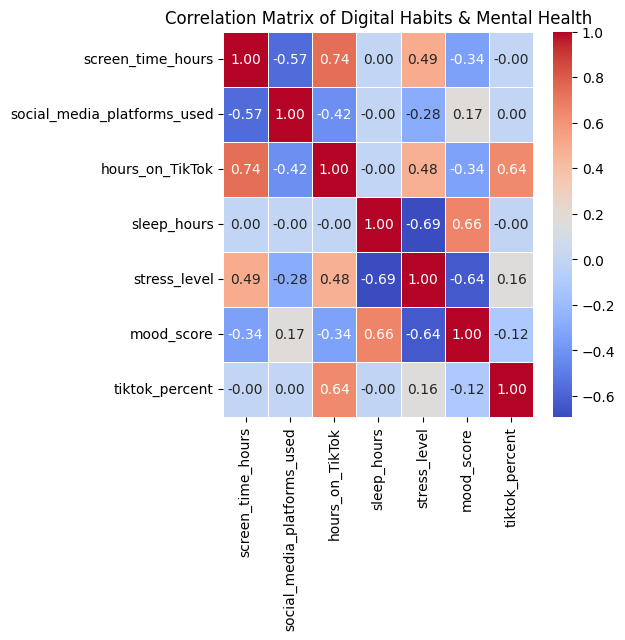

In [15]:
# 🔍 CORRELATION HEATMAP
plt.figure(figsize=(5,5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Digital Habits & Mental Health")
plt.show()

#🔎**Insights from Correlation Analysis**✨



🧪 **Screen time hours** show a moderate positive correlation with stress level, indicating that higher screen usage is associated with increased stress.  
🧪 **Hours spent on TikTok** also demonstrate a moderate positive correlation  with stress, suggesting a similar trend.  
🧪 **Social media platforms** indicates a weak negative correlation with stress and slightly associated with lower stress.  
🧪 **Sleep hours** exhibit a strong negative correlation with stress indicating that increased sleep duration is strongly associated with reduced stress levels.


#📈**Linear Regression Model for Stress Level Prediction**🔮

In [10]:
# Defining : Parameters (X) and Target (y)

X = df.drop("stress_level", axis=1)   # all independent variables
y = df["stress_level"]                # target variable


#Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# Applying Linear Regression

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


#Predictions

y_pred = model.predict(X_test)


#Model Evaluation

from sklearn.metrics import r2_score, mean_squared_error

print("R2 Score:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

R2 Score: 0.7469910636797239
Mean Squared Error: 1.0663041463144227


#📌**Insights from Linear Regression Model**  


*   The model achieved an R² score of 0.75, meaning approximately 75% of the variation in stress level is explained by the selected features.
*   The Mean Squared Error (1.06) is relatively low, indicating that the model’s predictions are reasonably accurate.
*   This suggests that lifestyle factors such as sleep, mood, and screen usage play a significant role in predicting stress levels.
*  The model demonstrates strong predictive capability for stress level estimation.



#🎯 Interpret Feature Importance

In [11]:
# Get Feature Coefficients
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
2,hours_on_TikTok,0.412868
0,screen_time_hours,0.352387
4,mood_score,0.044597
5,tiktok_percent,0.004195
1,social_media_platforms_used,-0.000159
3,sleep_hours,-0.987901


#💎**Insights for Feature Importance**



*  Sleep hours have the strongest negative impact, indicating that increased sleep significantly reduces stress levels.
*   Hours spent on TikTok and total screen time positively influence stress, suggesting higher usage increases stress.
*   Mood score shows a very small effect in the regression model
*   TikTok percentage and number of social media platforms used have negligible impact on stress prediction.


#🎯**Predicted vs Actual Stress Plot**📊

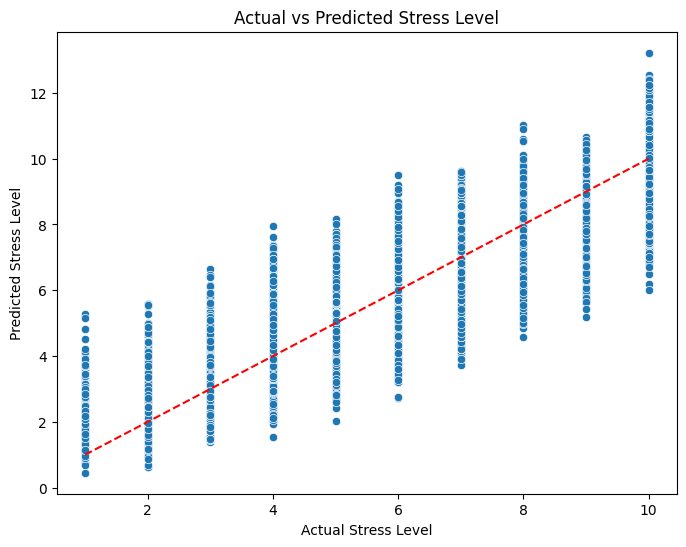

In [12]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Stress Level")
plt.ylabel("Predicted Stress Level")
plt.title("Actual vs Predicted Stress Level")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

# 🔎**Overall Conclusion**🤔



*   Correlation analysis showed that **sleep hours** and **mood score** have strong negative correlations with stress, while **screen time** and **hours on** **TikTok** have moderate positive correlations.
*   The Linear Regression model achieved an R² score of 0.75 and low MSE, indicating that it can reliably predict stress levels based on the selected features.


*   Feature importance analysis confirmed that sleep hours are the most influential factor in reducing stress, followed by hours on TikTok and total screen time.
*  Overall, the project suggests that increasing sleep and managing screen time can play a significant role in stress management for individuals.





#💡**Key Strategic Recommendations**



* ## **Prioritize 'Sleep Gain' over 'Screen Loss'** 😴

1.   **The Insight:** Analysis shows that Sleep Hours has a much stronger correlation with stress than Screen Time.
2.  **The Action:** Wellness strategies should prioritize getting one extra hour of sleep over simply cutting one hour of phone use. Sleep acts as a more powerful "buffer" against stress than digital reduction alone.  




* ## **Focus on Total Duration, Not App Diversity** ⏳


1.  **The Insight:** he total time spent on high-intensity apps (like TikTok) is the main driver of stress, regardless of how many different platforms a user visits.
2.  **The Action:** Users should set a hard limit on total daily screen hours. Reducing the "Total Usage" time is the most direct way to lower the predicted stress score in the model.



